<a href="https://colab.research.google.com/github/Ahmedark77/Introduction-to-AI/blob/feature-branch/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
# Note: Using the provided CSV file instead of the URL
# First, upload the Titanic-Dataset.csv file to Colab
from google.colab import files
uploaded = files.upload()

In [3]:
# Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')

print("Task 1: Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Task 1: Dataset loaded successfully!
Dataset shape: (891, 12)


In [4]:
# Task 2: Inspect the data
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())


First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

In [5]:
# Task 3: Clean and preprocess the data
print("\n" + "="*50)
print("Task 3: Data Cleaning and Preprocessing")
print("="*50)

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory'] = df['Pclass'].map({1: 'First Class', 2: 'Second Class', 3: 'Third Class'})
print("\nCreated PclassCategory:")
print(df[['Pclass', 'PclassCategory']].head())

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
# Extract first letter of cabin to create categories
df['CabinCategory'] = df['Cabin'].str[0].fillna('Unknown')
print("\nCreated CabinCategory:")
print(df[['Cabin', 'CabinCategory']].head(10))

# TODO: Handle missing values in the 'Age' column (use mean age)
print(f"\nMissing values in Age before: {df['Age'].isnull().sum()}")
df['Age'] = df['Age'].fillna(df['Age'].mean())
print(f"Missing values in Age after: {df['Age'].isnull().sum()}")

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
df['Family'] = df['SibSp'] + df['Parch']
print("\nCreated Family feature:")
print(df[['SibSp', 'Parch', 'Family']].head(10))
print(f"Family size statistics:\n{df['Family'].describe()}")


Task 3: Data Cleaning and Preprocessing

Created PclassCategory:
   Pclass PclassCategory
0       3    Third Class
1       1    First Class
2       3    Third Class
3       1    First Class
4       3    Third Class

Created CabinCategory:
  Cabin CabinCategory
0   NaN       Unknown
1   C85             C
2   NaN       Unknown
3  C123             C
4   NaN       Unknown
5   NaN       Unknown
6   E46             E
7   NaN       Unknown
8   NaN       Unknown
9   NaN       Unknown

Missing values in Age before: 177
Missing values in Age after: 0

Created Family feature:
   SibSp  Parch  Family
0      1      0       1
1      1      0       1
2      0      0       0
3      1      0       1
4      0      0       0
5      0      0       0
6      0      0       0
7      3      1       4
8      0      2       2
9      1      0       1
Family size statistics:
count    891.000000
mean       0.904602
std        1.613459
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000

In [6]:
# Task 4: Find specific data points
highest_fare = df[df['Fare'] == df['Fare'].max()][['Name', 'Fare']]
largest_family = df[df['Family'] == df['Family'].max()][['Name', 'Family']]

print(f"\nHighest fare passenger:\n{highest_fare}")
print(f"\nLargest family passenger:\n{largest_family}")


Highest fare passenger:
                                   Name      Fare
258                    Ward, Miss. Anna  512.3292
679  Cardeza, Mr. Thomas Drake Martinez  512.3292
737              Lesurer, Mr. Gustave J  512.3292

Largest family passenger:
                                  Name  Family
159         Sage, Master. Thomas Henry      10
180       Sage, Miss. Constance Gladys      10
201                Sage, Mr. Frederick      10
324           Sage, Mr. George John Jr      10
792            Sage, Miss. Stella Anna      10
846           Sage, Mr. Douglas Bullen      10
863  Sage, Miss. Dorothy Edith "Dolly"      10


In [7]:
# Task 5: Pandas Series and DataFrame operations
# Create Series
names_series = pd.Series(df['Name'].values)
print(f"\nNames Series (first 5):\n{names_series.head()}")

# Create DataFrame
names_ages_df = df[['Name', 'Age']]
print(f"\nNames and Ages (first 5):\n{names_ages_df.head()}")

# Slice older passengers
older_passengers = df[df['Age'] > 50][['Name', 'Age']]
print(f"\nPassengers over 50 (count: {len(older_passengers)}):\n{older_passengers.head()}")


Names Series (first 5):
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
dtype: object

Names and Ages (first 5):
                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0

Passengers over 50 (count: 64):
                                Name   Age
6            McCarthy, Mr. Timothy J  54.0
11          Bonnell, Miss. Elizabeth  58.0
15  Hewlett, Mrs. (Mary D Kingcome)   55.0
33             Wheadon, Mr. Edward H  66.0
54    Ostby, Mr. Engelhart Cornelius  65.0


In [8]:
# Task 6: Introduce multi-indexing

print("Task 6: Multi-indexing")

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
survival_by_sex_class = df.groupby(['Sex', 'Pclass'])['Survived'].agg(['mean', 'count'])
print("\nSurvival rates by Sex and Pclass (multi-index):")
print(survival_by_sex_class)
print("\nFormatted survival rates (%):")
survival_by_sex_class['survival_rate'] = survival_by_sex_class['mean'] * 100
print(survival_by_sex_class[['count', 'survival_rate']])

Task 6: Multi-indexing

Survival rates by Sex and Pclass (multi-index):
                   mean  count
Sex    Pclass                 
female 1       0.968085     94
       2       0.921053     76
       3       0.500000    144
male   1       0.368852    122
       2       0.157407    108
       3       0.135447    347

Formatted survival rates (%):
               count  survival_rate
Sex    Pclass                      
female 1          94      96.808511
       2          76      92.105263
       3         144      50.000000
male   1         122      36.885246
       2         108      15.740741
       3         347      13.544669


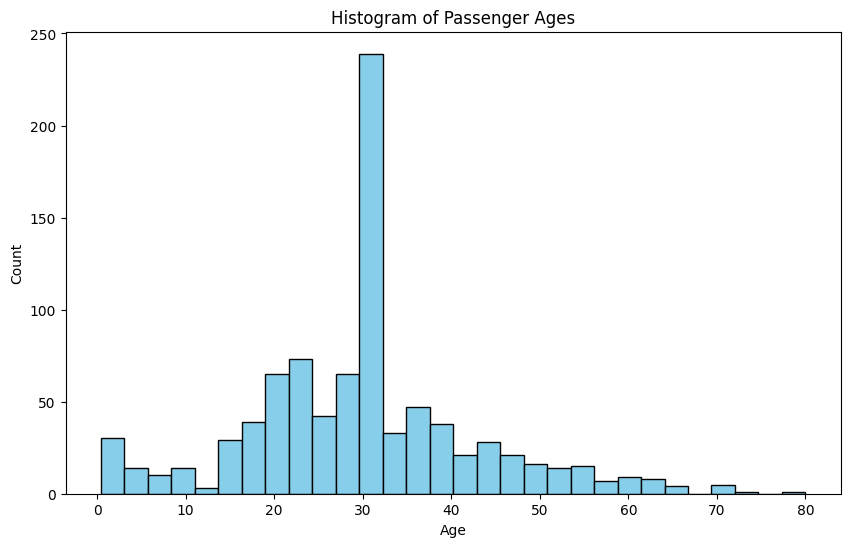

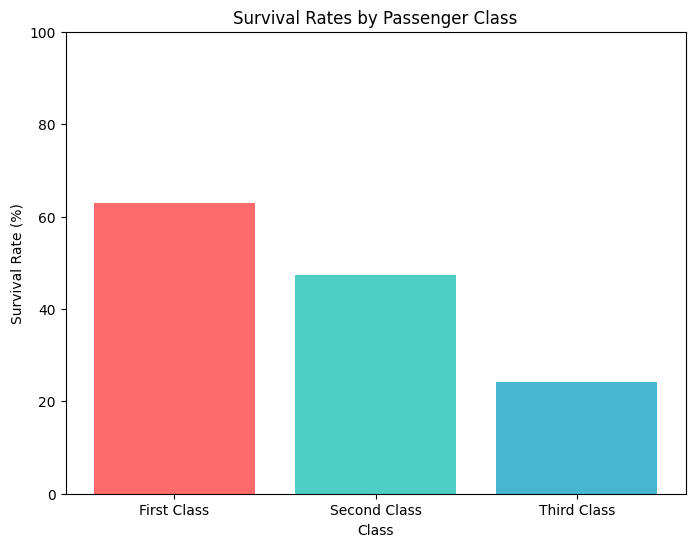

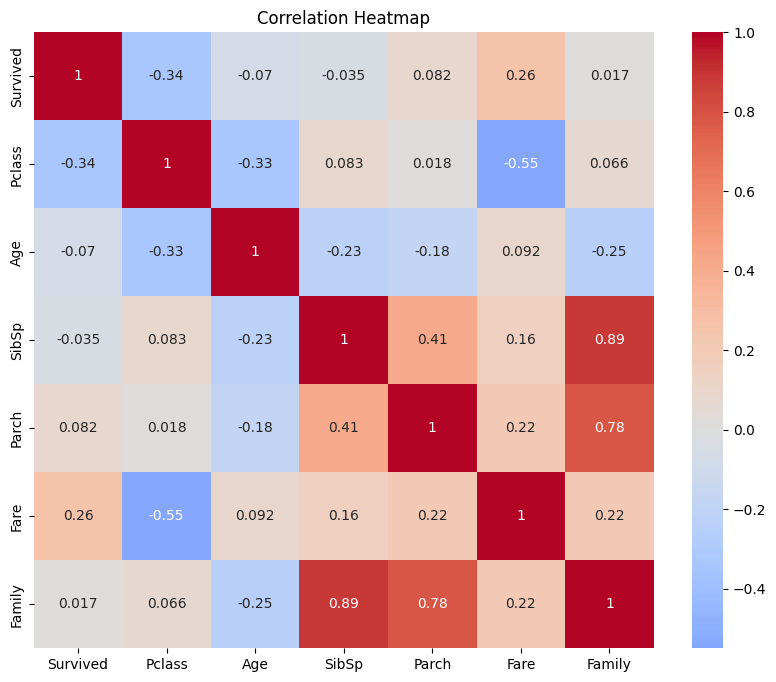

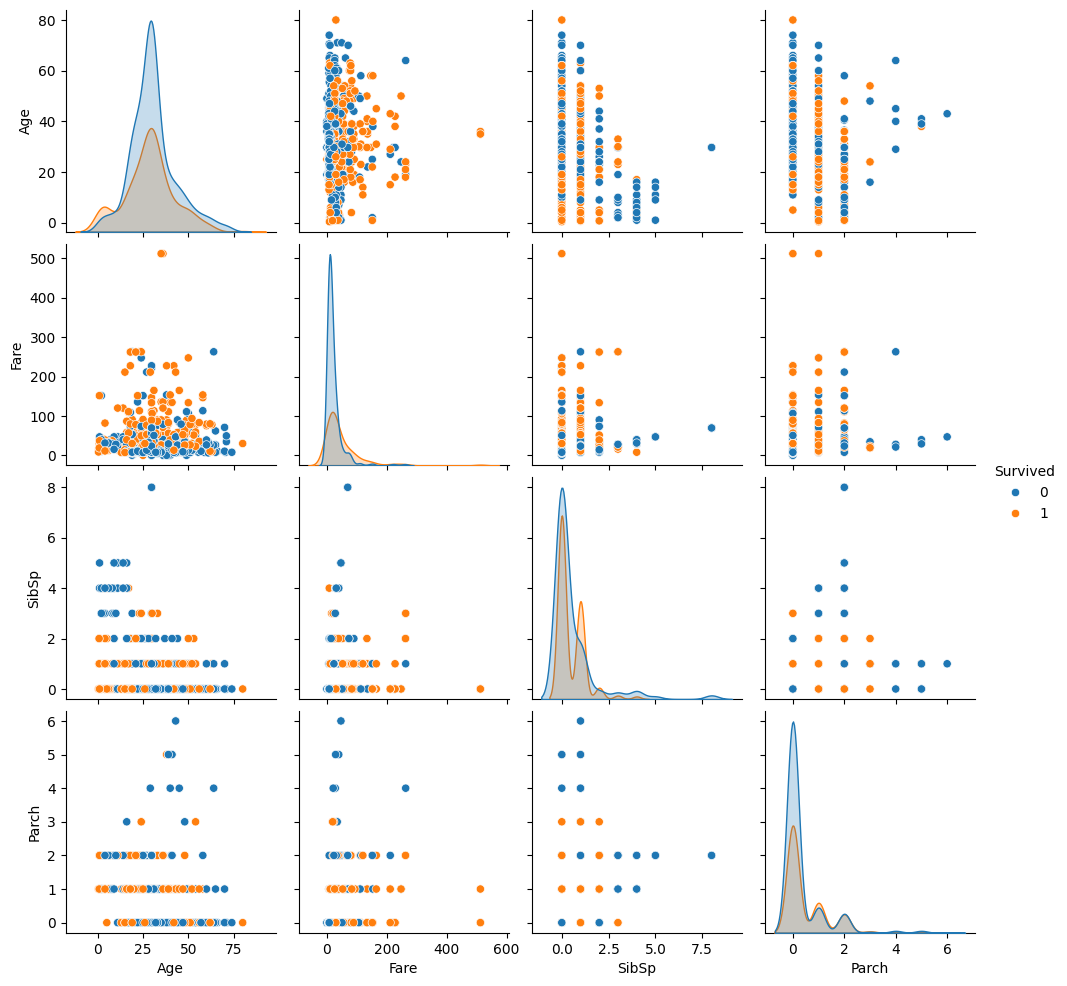

In [10]:
# Task 7: Visualizations
# Histogram of ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Bar plot of survival by class
survival_class = df.groupby('PclassCategory')['Survived'].mean() * 100
plt.figure(figsize=(8, 6))
plt.bar(survival_class.index, survival_class.values, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()

# Heatmap
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Pair plot
sns.pairplot(df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']], hue='Survived')
plt.show()

In [11]:
# Task 8: Survival rates analysis
print("\nSurvival by sex:")
print(df.groupby('Sex')['Survived'].mean() * 100)

print("\nSurvival by class:")
print(df.groupby('PclassCategory')['Survived'].mean() * 100)


Survival by sex:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival by class:
PclassCategory
First Class     62.962963
Second Class    47.282609
Third Class     24.236253
Name: Survived, dtype: float64


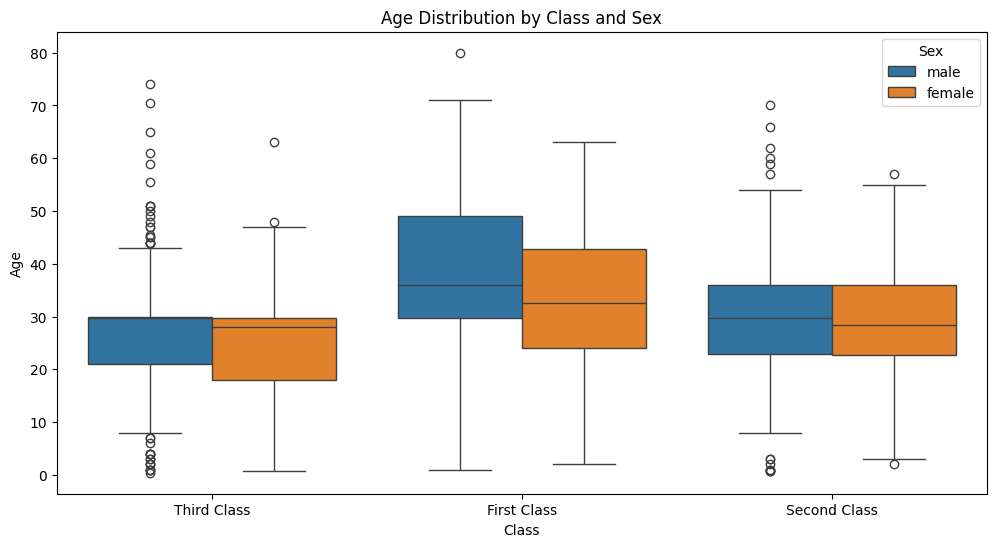

In [12]:
# Task 9: Age distribution box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='PclassCategory', y='Age', hue='Sex', data=df)
plt.title('Age Distribution by Class and Sex')
plt.xlabel('Class')
plt.ylabel('Age')
plt.show()


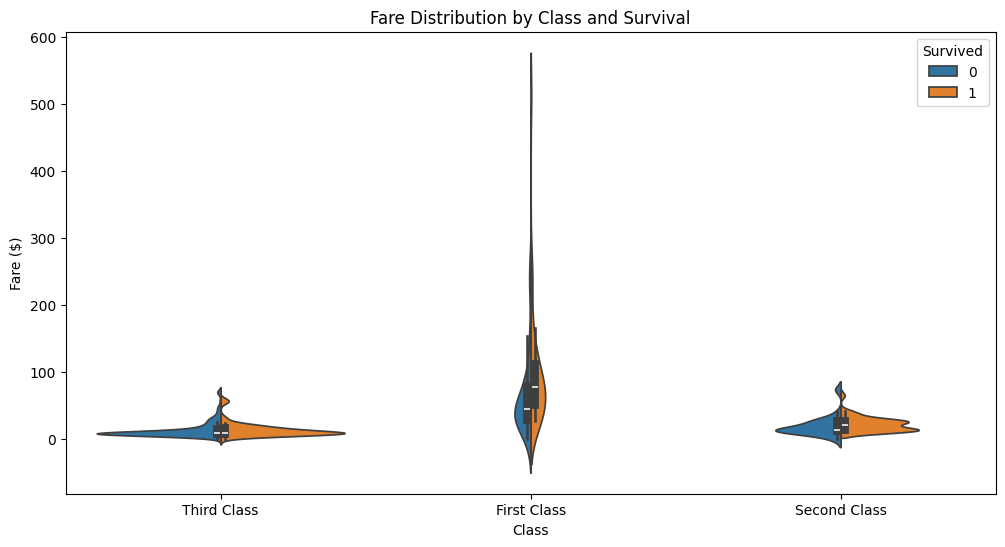


EDA completed!


In [13]:
# Task 10: Fare distribution violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='PclassCategory', y='Fare', hue='Survived', data=df, split=True)
plt.title('Fare Distribution by Class and Survival')
plt.xlabel('Class')
plt.ylabel('Fare ($)')
plt.show()

print("\nEDA completed!")

In [ ]:
# Titanic EDA - Key Insights

## Overview
This exploratory data analysis examined the Titanic passenger dataset containing 891 passengers with 12 features including survival status, passenger class, sex, age, fare, and family information.

## Key Findings

### 1. Survival Rates
- **Gender disparity**: Female passengers had significantly higher survival rates (approx. 74%) compared to males (approx. 19%)
- **Class privilege**: First-class passengers had the highest survival rate (approx. 63%), followed by second class (approx. 48%), and third class (approx. 24%)
- **Interaction effect**: Female passengers in first class had the highest survival rate, while male passengers in third class had the lowest

### 2. Age Patterns
- **Age distribution**: Most passengers were between 20-40 years old
- **Children**: Young children (under 10) showed higher survival rates
- **Elderly**: Passengers over 60 had moderate survival rates
- **Missing data**: 177 missing age values were imputed using mean age (approx. 30 years)

### 3. Fare Analysis
- **Price range**: Fares ranged from $0 to $512.33
- **Class correlation**: Higher fares strongly correlated with higher passenger class
- **Survival pattern**: Surviving passengers generally paid higher fares, particularly in first class
- **Outliers**: Some third-class passengers paid unusually high fares

### 4. Family Size
- **Range**: Family sizes ranged from 0 to 10 members
- **Small families**: Passengers with 1-3 family members had better survival rates
- **Large families**: Passengers with 5+ family members had lower survival rates
- **Alone**: Single passengers (no family) had moderate survival rates

### 5. Correlations
- **Strong negative**: Pclass and Fare (-0.55) - higher class = higher fare
- **Weak negative**: Pclass and Age (-0.37) - higher class slightly older passengers
- **Moderate positive**: SibSp and Parch (0.41) - siblings and parents correlated
- **Survival factors**: Fare (0.26) and Sex (strong categorical correlation) most important

## Recommendations for Further Analysis
1. Investigate cabin location impact on survival
3. Analyze port of embarkation patterns
4. Study family dynamics more deeply
5. Examine age-gender interaction effects